# China-Fundus-CIMT — CVD Risk Prediction Pipeline

End-to-end pipeline: load data → preprocess → CNN baseline → train → evaluate.

**Before running:** set `DATA_DIR` and `JSON_PATH` in the config cell below to match your unzipped folder.

Task: binary classification — predict CIMT thickened (≥0.9mm) vs normal (<0.9mm) from a fundus image.
This mirrors the paper's setup, so you have a published baseline (~77–81% accuracy, ~0.83–0.86 AUC) to compare against.


## 1. Setup & Config

In [6]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [7]:
# ----- EDIT THESE TWO PATHS IF NEEDED -----
DATA_DIR  = "/Users/anushmita/Documents/Screenshots/pbl/retinal fundus dataset/Fundus_CIMT_2903 Dataset"
JSON_PATH = "/Users/anushmita/Documents/Screenshots/pbl/retinal fundus dataset/data_info.json"
# --------------------------------------------

IMG_SIZE = 224          # resize target for the CNN (images ship at 512x512)
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4
# Note: labels (normal/thickened) come precomputed in the JSON as "label" -- no threshold needed here.


## 2. Load metadata & build a file-level dataframe

The dataset's JSON is keyed by patient ID and contains age, gender, and CIMT value.
Each patient has two images (left/right eye), with exact filenames given by the `left_eye`/`right_eye` fields in the JSON.
We flatten this into one row per image, since we're doing single-image classification for the baseline.

If your JSON's field names differ from what's assumed below (`age`, `gender`, `cimt`), adjust the `.get(...)` calls after printing one sample record.

In [8]:
with open(JSON_PATH, "r") as f:
    meta = json.load(f)

# Peek at structure so field names can be corrected if needed
sample_key = next(iter(meta))
print("Sample patient ID:", sample_key)
print("Sample record:", meta[sample_key])
print("Total patients in JSON:", len(meta))


Sample patient ID: 2491006
Sample record: {'gender': 0, 'thickness': 0.8, 'label': 0, 'group': 1, 'True_age': 63, 'age': 0.684931506849315, 'right_eye': '2491006_R.png', 'left_eye': '2491006_L.png'}
Total patients in JSON: 2903


In [9]:
# Actual schema (confirmed from the real data_info.json):
#   gender: 0/1
#   thickness: raw CIMT value in mm
#   label: precomputed 0=normal / 1=thickened -- already provided, no threshold needed
#   True_age: raw age in years
#   age: age pre-normalized to 0-1 by the dataset authors
#   right_eye / left_eye: exact image filenames

rows = []
missing_images = 0

for patient_id, record in meta.items():
    label = record["label"]

    for side_key, side_name in [("left_eye", "L"), ("right_eye", "R")]:
        fname = record.get(side_key)
        if not fname:
            continue
        fpath = os.path.join(DATA_DIR, fname)
        if not os.path.exists(fpath):
            missing_images += 1
            continue
        rows.append({
            "patient_id": patient_id,
            "filepath": fpath,
            "side": side_name,
            "true_age": record.get("True_age"),
            "age_norm": record.get("age"),
            "gender": record.get("gender"),
            "thickness": record.get("thickness"),
            "label": label
        })

df = pd.DataFrame(rows)
print(f"Total image rows: {len(df)}   |  Missing image files skipped: {missing_images}")
print(df["label"].value_counts().rename({0: "normal", 1: "thickened"}))
df.head()


Total image rows: 5806   |  Missing image files skipped: 0
label
thickened    4108
normal       1698
Name: count, dtype: int64


,patient_id,filepath,side,true_age,age_norm,gender,thickness,label
0,2491006,/Users/anushmita/Documents/Screenshots/pbl/ret...,L,63,0.684932,0,0.8,0
1,2491006,/Users/anushmita/Documents/Screenshots/pbl/ret...,R,63,0.684932,0,0.8,0
2,3730004,/Users/anushmita/Documents/Screenshots/pbl/ret...,L,61,0.657534,1,1.2,1
3,3730004,/Users/anushmita/Documents/Screenshots/pbl/ret...,R,61,0.657534,1,1.2,1
4,3730006,/Users/anushmita/Documents/Screenshots/pbl/ret...,L,64,0.698630,1,1.2,1


## 3. visualize a few samples

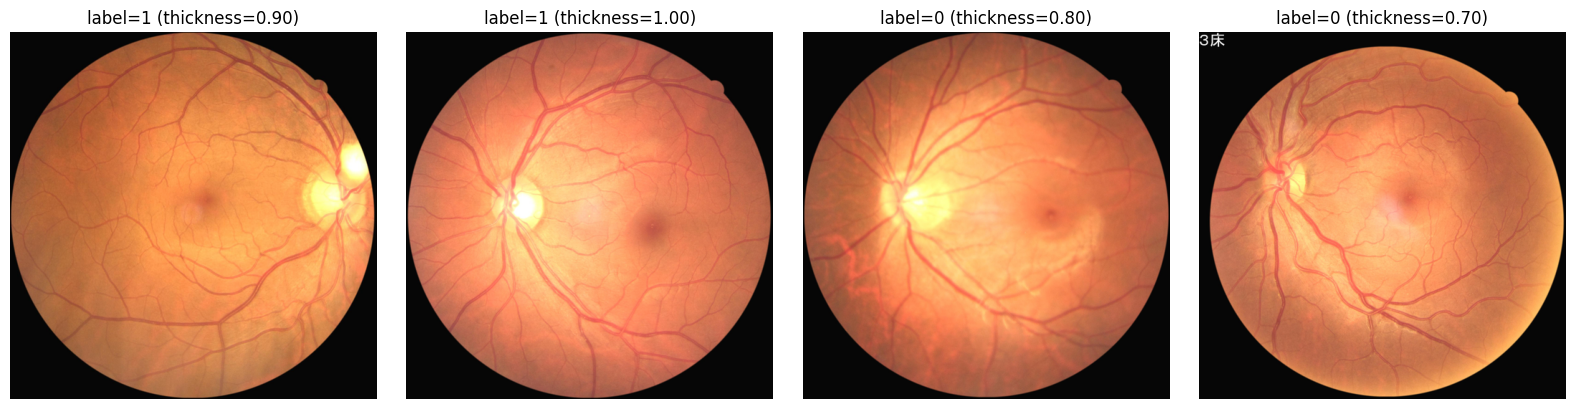

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sample_rows = df.sample(4, random_state=SEED)
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img = Image.open(row["filepath"])
    ax.imshow(img)
    ax.set_title(f"label={row['label']} (thickness={row['thickness']:.2f})")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Train / validation / test split

Split at the **patient level**, not image level — otherwise both eyes of the same patient
could land in different splits, leaking information (they're highly correlated).

In [11]:
patient_labels = df.groupby("patient_id")["label"].first().reset_index()

train_ids, temp_ids = train_test_split(
    patient_labels["patient_id"], test_size=0.3, stratify=patient_labels["label"], random_state=SEED
)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.5,
    stratify=patient_labels.set_index("patient_id").loc[temp_ids, "label"],
    random_state=SEED
)

train_df = df[df["patient_id"].isin(train_ids)].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(val_ids)].reset_index(drop=True)
test_df  = df[df["patient_id"].isin(test_ids)].reset_index(drop=True)

print(f"Train: {len(train_df)} images / {train_ids.nunique()} patients")
print(f"Val:   {len(val_df)} images / {val_ids.nunique()} patients")
print(f"Test:  {len(test_df)} images / {test_ids.nunique()} patients")


Train: 4064 images / 2032 patients
Val:   870 images / 435 patients
Test:  872 images / 436 patients


## 5. Dataset & DataLoaders

In [12]:
class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row["label"], dtype=torch.long)
        return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = FundusDataset(train_df, transform=train_transform)
val_ds   = FundusDataset(val_df, transform=eval_transform)
test_ds  = FundusDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


## 6. Model — ResNet18 baseline (transfer learning)

Starting point matching the literature's approach (CNN on raw fundus images). Swap this out later for
your GNN pipeline once vessel graphs are built — this gives you a number to beat.

In [13]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)  # binary classification
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)


## 7. Training loop

In [14]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    torch.set_grad_enabled(train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if train:
            optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("  -> saved new best model")


Epoch 1/15 | train_loss=0.5177 train_acc=0.7507 | val_loss=0.5039 val_acc=0.7724
  -> saved new best model
Epoch 2/15 | train_loss=0.4730 train_acc=0.7781 | val_loss=0.4723 val_acc=0.7874
  -> saved new best model
Epoch 3/15 | train_loss=0.4530 train_acc=0.7950 | val_loss=0.4606 val_acc=0.7931
  -> saved new best model
Epoch 4/15 | train_loss=0.4397 train_acc=0.7963 | val_loss=0.5095 val_acc=0.7920
Epoch 5/15 | train_loss=0.4137 train_acc=0.8135 | val_loss=0.4913 val_acc=0.7736
Epoch 6/15 | train_loss=0.3909 train_acc=0.8201 | val_loss=0.5133 val_acc=0.7644
Epoch 7/15 | train_loss=0.3201 train_acc=0.8647 | val_loss=0.5086 val_acc=0.7931
Epoch 8/15 | train_loss=0.2779 train_acc=0.8878 | val_loss=0.6012 val_acc=0.7598
Epoch 9/15 | train_loss=0.2423 train_acc=0.8984 | val_loss=0.5838 val_acc=0.7701
Epoch 10/15 | train_loss=0.1836 train_acc=0.9242 | val_loss=0.6236 val_acc=0.7828
Epoch 11/15 | train_loss=0.1449 train_acc=0.9444 | val_loss=0.6885 val_acc=0.7609
Epoch 12/15 | train_loss=0.13

## 8. Training curves

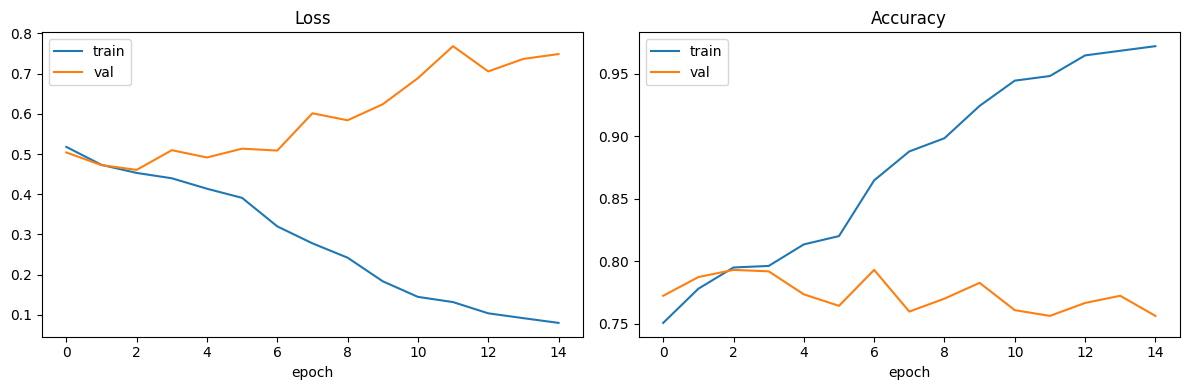

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Test set evaluation

Loads the best checkpoint (lowest val loss) and reports accuracy, AUC-ROC, confusion matrix,
and a full classification report — directly comparable to the paper's reported metrics
(~75-81% accuracy, ~0.83-0.86 AUC for the unimodal image-only model).

In [21]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class 1 (thickened)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
np.save("cnn_test_probs.npy", np.array(all_probs))
test_df.reset_index(drop=True)["patient_id"].to_csv("cnn_test_probs_pids.csv", index=False)   

acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC-ROC:  {auc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=["normal", "thickened"]))
# Clinically relevant metrics for CVD risk prediction
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

sensitivity = tp / (tp + fn)                # Recall / True Positive Rate
specificity = tn / (tn + fp)                # True Negative Rate
ppv = tp / (tp + fp)                        # Precision / Positive Predictive Value
npv = tn / (tn + fn)                        # Negative Predictive Value
f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity)
youden_j = sensitivity + specificity - 1    # Youden's Index
balanced_acc = (sensitivity + specificity) / 2

print(f"Sensitivity (Recall):     {sensitivity:.4f}")
print(f"Specificity:               {specificity:.4f}")
print(f"PPV (Precision):           {ppv:.4f}")
print(f"NPV:                       {npv:.4f}")
print(f"F1-score:                  {f1:.4f}")
print(f"Youden's J Index:          {youden_j:.4f}")
print(f"Balanced Accuracy:         {balanced_acc:.4f}")
print(f"AUC-ROC:                   {auc:.4f}")  # already computed above, restated for a single summary block


Test Accuracy: 0.7913
Test AUC-ROC:  0.8335

              precision    recall  f1-score   support

      normal       0.67      0.57      0.62       256
   thickened       0.83      0.88      0.86       616

    accuracy                           0.79       872
   macro avg       0.75      0.73      0.74       872
weighted avg       0.78      0.79      0.79       872

Sensitivity (Recall):     0.8815
Specificity:               0.5742
PPV (Precision):           0.8328
NPV:                       0.6682
F1-score:                  0.8565
Youden's J Index:          0.4557
Balanced Accuracy:         0.7279
AUC-ROC:                   0.8335


In [25]:
# Also compute and save CNN probabilities on the VALIDATION set (needed for ensemble threshold tuning)
model.eval()
val_probs_list, val_pids_list = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        val_probs_list.extend(probs.cpu().numpy())

val_pids_list = val_df["patient_id"].astype(str).tolist()

np.save("cnn_val_probs.npy", np.array(val_probs_list))
pd.Series(val_pids_list, name="patient_id").to_csv("cnn_val_probs_pids.csv", index=False)
print(f"Saved {len(val_probs_list)} CNN validation probabilities.")

Saved 870 CNN validation probabilities.


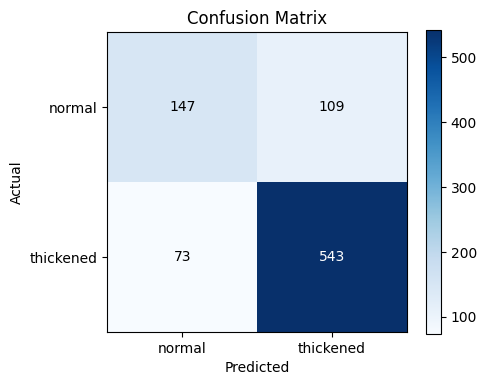

In [22]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["normal", "thickened"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["normal", "thickened"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.title("Confusion Matrix")
plt.colorbar(im)
plt.tight_layout()
plt.show()


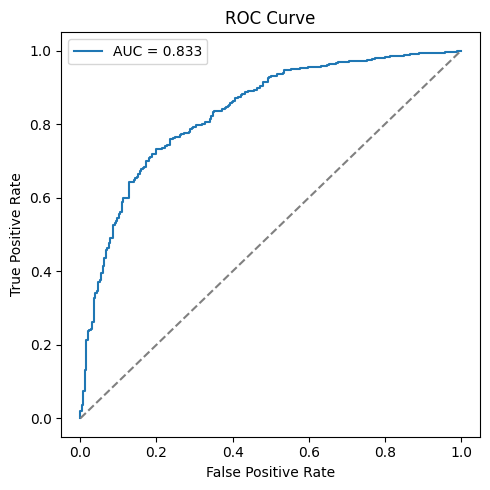

In [23]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Next steps

- **Multimodal version**: concatenate `age_norm` (already 0-1 normalized) + `gender` (one-hot) with the CNN's penultimate-layer features before the final classifier — the paper shows this adds ~3-8% AUC.
- **GNN pipeline**: segment vessels (e.g. with a pretrained vessel-segmentation model), build a graph from the vasculature skeleton (nodes = branch points, edges = vessel segments), and feed that into a GCN/GAT instead of, or alongside, this CNN.
- Save `train_df`/`val_df`/`test_df` patient ID splits to disk now so any future model (multimodal, GNN) uses the *exact same* split for fair comparison.

In [24]:
train_ids.to_csv("train_patient_ids.csv", index=False)
val_ids.to_csv("val_patient_ids.csv", index=False)
test_ids.to_csv("test_patient_ids.csv", index=False)
print("Splits saved — reuse these for every future model.")

Splits saved — reuse these for every future model.
